# Custom Cubic Spline Program

## Setup

In [1]:
import numpy as np
from numpy import ndarray, array
import matplotlib.pyplot as plt

## 1. Data points

In [2]:
x: ndarray = array([1.0, 2.1, 2.9, 4.3, 5.0])
y: ndarray = array([1.1, 2.5, 3.3, 2.2, 4.7])

## 2. Step sizes

In [3]:
h: ndarray = np.diff(x)
dy: ndarray = np.diff(y)

## 3. Tridiagonal system

In [4]:
a: ndarray = np.zeros_like(h)
b: ndarray = np.zeros_like(h)
c: ndarray = np.zeros_like(x)
d: ndarray = np.zeros_like(h)

# Build the tridiagonal system
rhs: ndarray = 3 * (dy[1:] / h[1:] - dy[:-1] / h[:-1])
low: ndarray = h[1:-1].copy()
mid: ndarray = 2 * (h[:-1] + h[1:])
high: ndarray = h[1:-1].copy()
    
# Thomas algorithm
for i in range(1, len(x)-2):
    mid[i] -= low[i - 1] / mid[i - 1] * high[i - 1]
    rhs[i] -= low[i - 1] / mid[i - 1] * rhs[i - 1]
c[-2] = rhs[-1] / mid[-1]
for i in range(len(x)-4, -1, -1):
    c[i+1] = (rhs[i] - high[i] * c[i+2]) / mid[i]

d = np.diff(c) / (3 * h)
b = dy / h - h * (2 * c[:-1] + c[1:]) / 3
a = y[:-1]

## 4. Evaluate

In [5]:
def spline(x1: float):
    if x1 in x:
        return y[np.where(x == x1)[0][0]]
    i: int = np.searchsorted(x, x1, side='right') - 1
    if x1 % 1.0 == 0.0:
        print(x1, i)
    return a[i] + b[i]*(x1-x[i]) + c[i]*(x1-x[i])**2 + d[i]*(x1-x[i])**3

x_eval: ndarray = np.linspace(1,5,100)
y_eval: ndarray = array([spline(u) for u in x_eval])

## 5. Graph

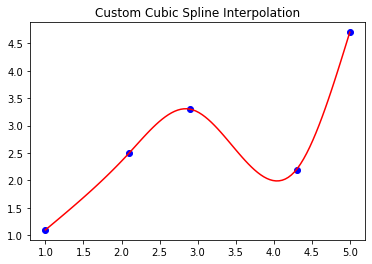

In [6]:
plt.plot(x,y,'bo',label="Data")
plt.plot(x_eval,y_eval,'r-',label="Spline")
plt.title("Custom Cubic Spline Interpolation")
plt.show()